# 🗽 New York City Crime Intelligence — Pipeline ML Complet

## Contexte Business
> *"Le NYPD traite +200 000 arrestations par an. Notre système prédit la sévérité d'un crime et le profil probable du criminel pour optimiser l'allocation des ressources policières."*

## Pourquoi NYC ?
- **Données démographiques** incluses (âge, genre) → profiling natif impossible sur Chicago
- **Felony/Misdemeanor** = cible de sévérité claire et équilibrée
- **5 boroughs** = structure géographique naturelle pour K-Means

## Pipeline
```
Step 0 — K-Means      : 5 zones géographiques (boroughs)
Step 1 — RF           : Type de crime (4 groupes)
Step 2 — XGBoost      : Sévérité (Felony / Misdemeanor / Violation)
Step 3 — RF Profiling : Tranche d'âge + Genre du criminel
Step 4 — RF Temporel  : Quel crime demain à 23h dans le Bronx ?
```

| | |
|---|---|
| **Source** | NYC Open Data — NYPD Arrests |
| **URL** | https://data.cityofnewyork.us/resource/uip8-fykc.json |
| **Volume** | ~150 000 arrestations |
| **Features** | date, crime, sévérité, borough, âge, genre, coordonnées |


## ⚙️ 0 — Imports

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib requests --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests, warnings, joblib, os
from io import StringIO

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi':120, 'figure.facecolor':'white'})
RANDOM_STATE = 42
print('✅ Imports OK')


✅ Imports OK


## 📥 1 — Chargement des Données NYC

In [2]:
# NYC NYPD Arrests — dataset complet avec démographie
print('⏳ Chargement NYC NYPD Arrests...')

# Année en cours
URL_CURRENT = 'https://data.cityofnewyork.us/resource/uip8-fykc.json'
# Historique (si besoin de plus de données)
URL_HISTORIC = 'https://data.cityofnewyork.us/resource/8h9b-rp9u.json'

PARAMS = {
    '$limit': 200000,
    '$order': 'arrest_date DESC',
    '$select': 'arrest_date,ofns_desc,pd_desc,law_cat_cd,arrest_boro,age_group,perp_sex,perp_race,latitude,longitude'
}

try:
    r = requests.get(URL_CURRENT, params=PARAMS, timeout=120)
    r.raise_for_status()
    df_raw = pd.DataFrame(r.json())
    print(f'✅ {len(df_raw):,} arrestations chargées (année en cours)')
except Exception as e:
    print(f'⚠️ {e} — tentative historique...')
    PARAMS['$where'] = 'arrest_date >= "2022-01-01"'
    r = requests.get(URL_HISTORIC, params=PARAMS, timeout=120)
    df_raw = pd.DataFrame(r.json())
    print(f'✅ {len(df_raw):,} arrestations chargées (historique)')

print(f'Colonnes : {df_raw.columns.tolist()}')
df_raw.head(3)


⏳ Chargement NYC NYPD Arrests...
✅ 69,305 arrestations chargées (année en cours)
Colonnes : ['arrest_date', 'ofns_desc', 'pd_desc', 'law_cat_cd', 'arrest_boro', 'age_group', 'perp_sex', 'perp_race', 'latitude', 'longitude']


,arrest_date,ofns_desc,pd_desc,law_cat_cd,arrest_boro,age_group,perp_sex,perp_race,latitude,longitude
0,2026-03-31T00:00:00.000,FELONY ASSAULT,ASSAULT POLICE/PEACE OFFICER,F,S,25-44,M,WHITE,40.645005,-74.077265
1,2026-03-31T00:00:00.000,FELONY ASSAULT,ASSAULT POLICE/PEACE OFFICER,F,B,25-44,M,WHITE HISPANIC,40.849048,-73.889519
2,2026-03-31T00:00:00.000,ROBBERY,"ROBBERY,OPEN AREA UNCLASSIFIED",F,B,18-24,M,BLACK HISPANIC,40.837782,-73.919457


## 🔍 2 — EDA

In [3]:
print('='*60)
print('  STATISTIQUES GÉNÉRALES — NYC NYPD ARRESTS')
print('='*60)
print(f'  Lignes          : {len(df_raw):,}')
print(f'  Colonnes        : {df_raw.shape[1]}')
print(f'\n  Sévérité :')
for v, n in df_raw['law_cat_cd'].value_counts().items():
    print(f'    {v} → {n:,} ({n/len(df_raw)*100:.1f}%)')
print(f'\n  Boroughs :')
for v, n in df_raw['arrest_boro'].value_counts().items():
    print(f'    {v} → {n:,} ({n/len(df_raw)*100:.1f}%)')
print(f'\n  Tranches d\'âge :')
print(df_raw['age_group'].value_counts())
print(f'\n  Genre :')
print(df_raw['perp_sex'].value_counts())


  STATISTIQUES GÉNÉRALES — NYC NYPD ARRESTS
  Lignes          : 69,305
  Colonnes        : 10

  Sévérité :
    M → 40,761 (58.8%)
    F → 26,889 (38.8%)
    V → 1,123 (1.6%)
    9 → 210 (0.3%)
    I → 53 (0.1%)
    (null) → 2 (0.0%)

  Boroughs :
    K → 21,111 (30.5%)
    M → 15,870 (22.9%)
    B → 15,613 (22.5%)
    Q → 14,160 (20.4%)
    S → 2,551 (3.7%)

  Tranches d'âge :
age_group
25-44     30798
(null)    16933
45-64     11386
18-24      7065
<18        1958
65+        1165
Name: count, dtype: int64

  Genre :
perp_sex
M         42719
(null)    16933
F          9653
Name: count, dtype: int64


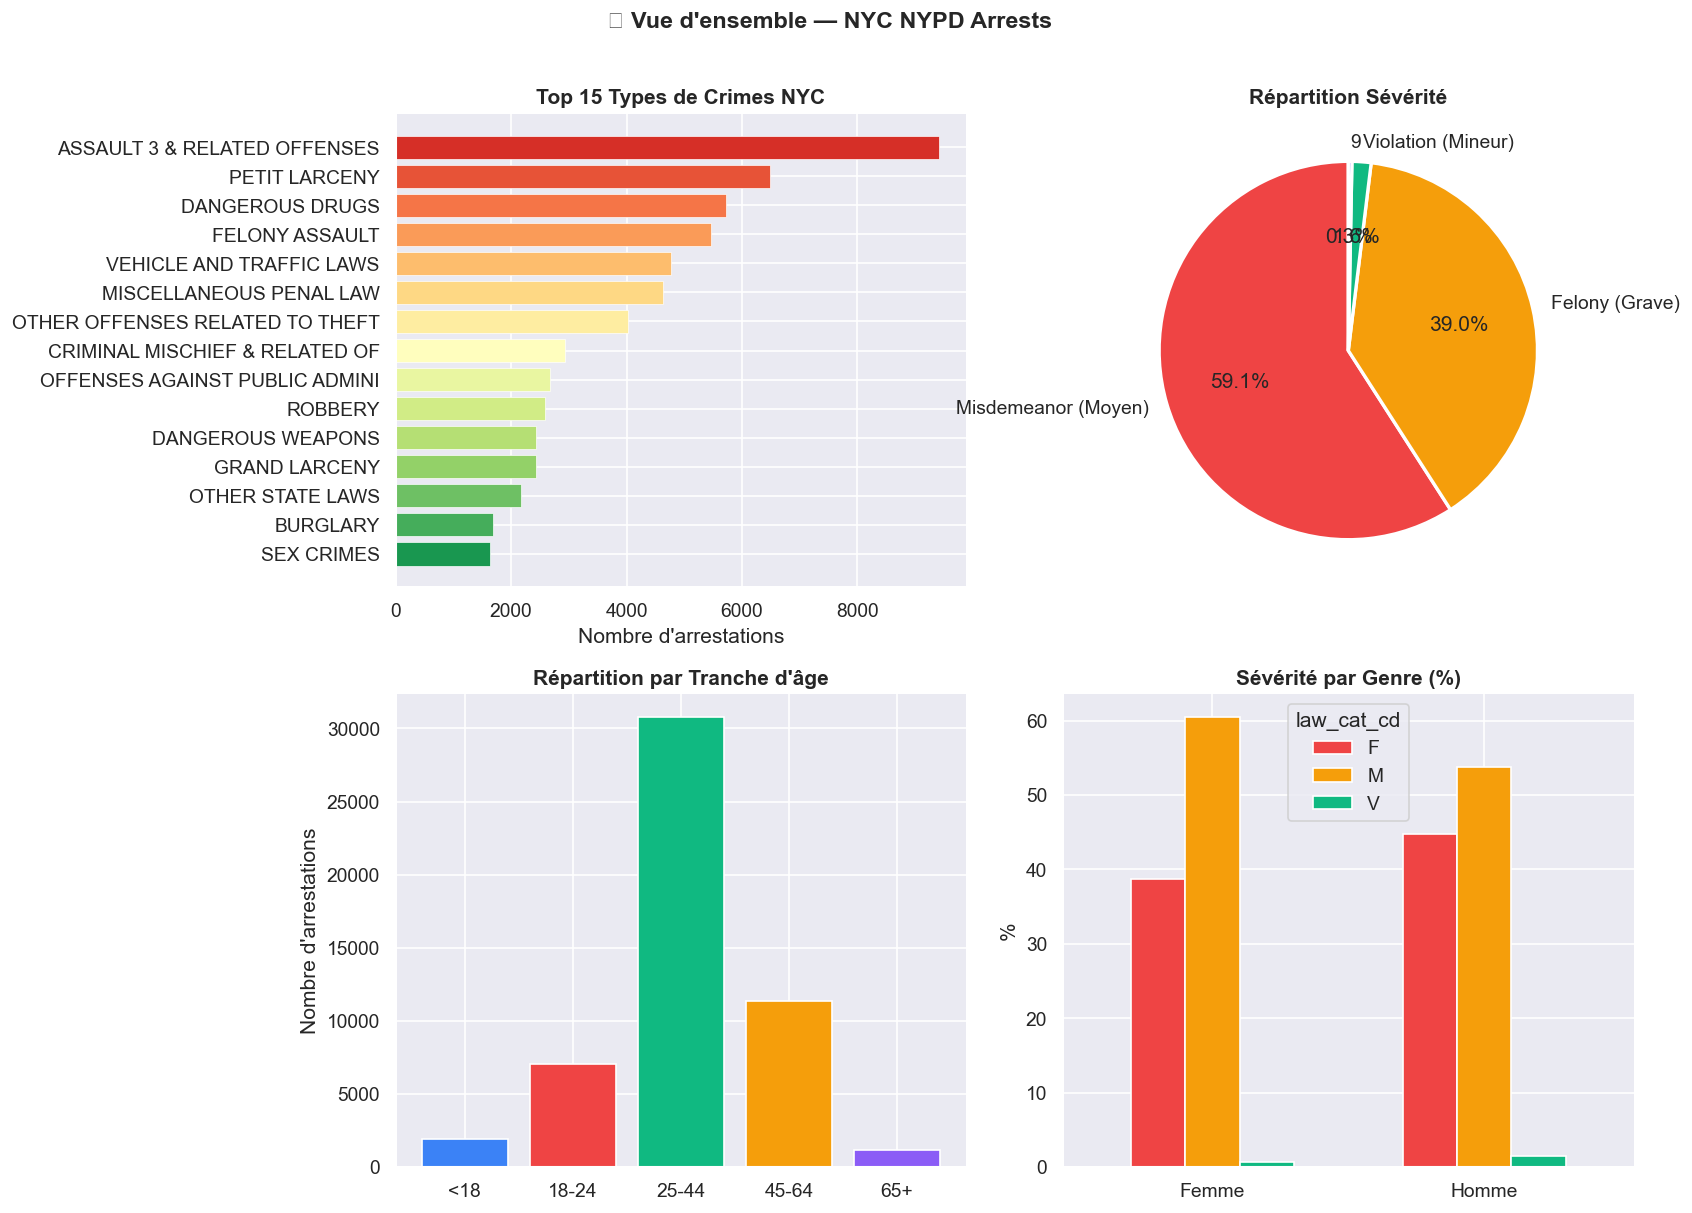

✅ viz_01_overview.png


In [4]:
# ── VIZ 1 : Vue d'ensemble NYC ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top crimes
top15 = df_raw['ofns_desc'].value_counts().head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 15))
axes[0,0].barh(top15.index[::-1], top15.values[::-1], color=colors, edgecolor='white', lw=0.4)
axes[0,0].set_title('Top 15 Types de Crimes NYC', fontweight='bold')
axes[0,0].set_xlabel("Nombre d'arrestations")
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

# Sévérité
sev_map = {'F':'Felony (Grave)', 'M':'Misdemeanor (Moyen)', 'V':'Violation (Mineur)', 'I':'Infraction'}
sev_counts = df_raw['law_cat_cd'].value_counts().head(4)
sev_colors = ['#ef4444','#f59e0b','#10b981','#6366f1']
axes[0,1].pie(sev_counts.values,
              labels=[sev_map.get(k,k) for k in sev_counts.index],
              colors=sev_colors, autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,1].set_title('Répartition Sévérité', fontweight='bold')

# Âge
df_raw['date_p'] = pd.to_datetime(df_raw['arrest_date'], errors='coerce')
df_raw['hour'] = df_raw['date_p'].dt.hour.fillna(12).astype(int)
age_order = ['<18','18-24','25-44','45-64','65+']
age_counts = df_raw['age_group'].value_counts().reindex(
    [a for a in age_order if a in df_raw['age_group'].unique()], fill_value=0)
axes[1,0].bar(age_counts.index, age_counts.values,
              color=['#3b82f6','#ef4444','#10b981','#f59e0b','#8b5cf6'][:len(age_counts)],
              edgecolor='white')
axes[1,0].set_title("Répartition par Tranche d'âge", fontweight='bold')
axes[1,0].set_ylabel("Nombre d'arrestations")
axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

# Genre × Sévérité
gender_sev = df_raw[df_raw['perp_sex'].isin(['M','F'])].groupby(
    ['perp_sex','law_cat_cd']).size().unstack(fill_value=0)
gender_sev = gender_sev.reindex(columns=['F','M','V'], fill_value=0)
gender_sev.index = ['Femme','Homme']
gender_sev.div(gender_sev.sum(axis=1), axis=0).mul(100).plot(
    kind='bar', ax=axes[1,1],
    color=['#ef4444','#f59e0b','#10b981'], edgecolor='white', width=0.6)
axes[1,1].set_title('Sévérité par Genre (%)', fontweight='bold')
axes[1,1].set_ylabel('%'); axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

plt.suptitle('🗽 Vue d\'ensemble — NYC NYPD Arrests', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_01_overview.png', bbox_inches='tight')
plt.show()
print('✅ viz_01_overview.png')


ValueError: x and y must have same first dimension, but have shapes (24,) and (1,)

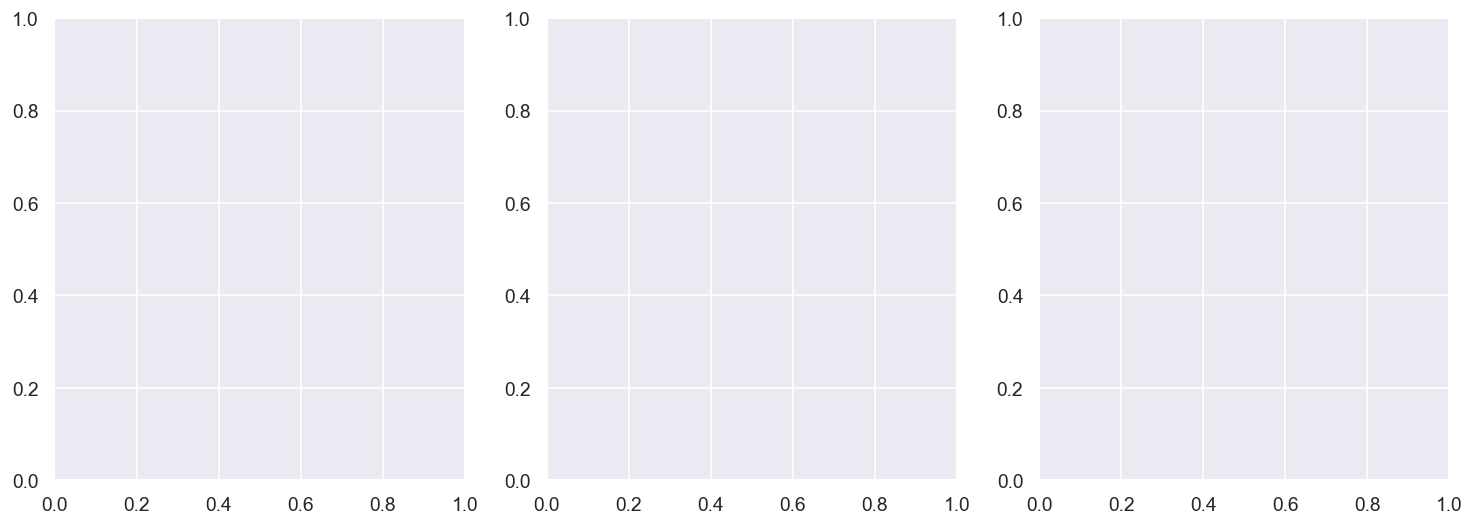

In [5]:
# ── VIZ 2 : Patterns temporels ──
df_raw['day_of_week'] = df_raw['date_p'].dt.dayofweek.fillna(0).astype(int)
df_raw['month']       = df_raw['date_p'].dt.month.fillna(6).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Par heure
hour_sev = df_raw[df_raw['law_cat_cd'].isin(['F','M'])].groupby(
    ['hour','law_cat_cd']).size().unstack(fill_value=0)
if 'F' in hour_sev.columns:
    axes[0].plot(range(24), hour_sev['F'], 'o-', color='#ef4444', lw=2, ms=4, label='Felony')
if 'M' in hour_sev.columns:
    axes[0].plot(range(24), hour_sev['M'], 's-', color='#f59e0b', lw=2, ms=4, label='Misdemeanor')
axes[0].set_title('Arrestations par Heure', fontweight='bold')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel("Nombre"); axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Par jour
days_fr = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
day_counts = df_raw['day_of_week'].value_counts().sort_index()
axes[1].bar(range(7), day_counts.values, color='#3b82f6', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(days_fr)
axes[1].set_title('Volume par Jour', fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Par borough
boro_map_name = {'M':'Manhattan','K':'Brooklyn','B':'Bronx','Q':'Queens','S':'Staten Island'}
boro_counts = df_raw['arrest_boro'].value_counts()
boro_colors = ['#3b82f6','#ef4444','#f59e0b','#10b981','#8b5cf6']
axes[2].bar([boro_map_name.get(k,k) for k in boro_counts.index],
            boro_counts.values, color=boro_colors[:len(boro_counts)], edgecolor='white')
axes[2].set_title('Arrestations par Borough', fontweight='bold')
axes[2].set_ylabel("Nombre"); axes[2].tick_params(axis='x', rotation=20)
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('⏰ Patterns Temporels — NYC', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_02_temporal.png', bbox_inches='tight')
plt.show()


## 🧹 3 — Feature Engineering

In [ ]:
df = df_raw.copy()

# Coordonnées
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude','longitude','ofns_desc','law_cat_cd'])
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)]

# Temporel
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Borough → location_group
boro_num = {'M':0,'K':1,'B':2,'Q':3,'S':4}
df['location_group'] = df['arrest_boro'].map(boro_num).fillna(0).astype(int)

# ── CIBLE 1 : Type de crime (4 groupes) ──
def group_crime(crime):
    if pd.isna(crime): return 'PUBLIC ORDER'
    c = str(crime).upper()
    if any(w in c for w in ['ASSAULT','ROBBERY','WEAPON','HOMICIDE','RAPE','SEX CRIME']): return 'VIOLENT'
    if any(w in c for w in ['THEFT','LARCENY','BURGLARY','VEHICLE','FRAUD','FORGERY']): return 'PROPERTY'
    if any(w in c for w in ['DRUG','NARCOTIC','CONTROLLED','MARIJUANA']): return 'DRUG'
    return 'PUBLIC ORDER'

df['crime_group'] = df['ofns_desc'].apply(group_crime)
le_group = LabelEncoder()
df['crime_encoded'] = le_group.fit_transform(df['crime_group'])

# ── CIBLE 2 : Sévérité ──
sev_map_num = {'F':'FELONY','M':'MISDEMEANOR','V':'VIOLATION','I':'VIOLATION'}
df['severity']     = df['law_cat_cd'].map(sev_map_num).fillna('MISDEMEANOR')
le_sev             = LabelEncoder()
df['sev_encoded']  = le_sev.fit_transform(df['severity'])

# ── CIBLE 3 : Profiling — Âge ──
valid_ages = ['<18','18-24','25-44','45-64','65+']
df['age_clean'] = df['age_group'].apply(lambda x: x if x in valid_ages else None)
df = df.dropna(subset=['age_clean'])
le_age = LabelEncoder()
df['age_encoded'] = le_age.fit_transform(df['age_clean'])

# ── CIBLE 4 : Profiling — Genre ──
df['gender_clean'] = df['perp_sex'].map({'M':0,'F':1})
df = df.dropna(subset=['gender_clean'])
df['gender_clean'] = df['gender_clean'].astype(int)

print(f'✅ Dataset final : {len(df):,} lignes')
print(f'\n📊 Groupes crimes : {df["crime_group"].value_counts().to_dict()}')
print(f'\n🎯 Sévérité :')
print(df['severity'].value_counts())
print(f'\n👤 Âges :')
print(df['age_clean'].value_counts())
print(f'\n⚤ Genre : Homme={( df["gender_clean"]==0).sum():,} | Femme={(df["gender_clean"]==1).sum():,}')


## 🗺️ 4 — K-Means : Zones Géographiques NYC

In [ ]:
coords = df[['latitude','longitude']].sample(min(60000,len(df)), random_state=RANDOM_STATE)
scaler_kmeans = StandardScaler()
X_geo = scaler_kmeans.fit_transform(coords)

# Elbow
inertias = []
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    inertias.append(km.fit(X_geo).inertia_)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(2,9), inertias, 'o-', color='#3b82f6', lw=2.5, ms=8)
ax.axvline(x=5, color='#ef4444', linestyle='--', lw=1.8, label='k=5 retenu (= 5 boroughs)')
ax.set_xlabel('k'); ax.set_ylabel('Inertie')
ax.set_title('Méthode Elbow — k=5 correspond aux 5 boroughs NYC', fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('viz_03_elbow.png', bbox_inches='tight')
plt.show()

kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_geo)
coords_c = coords.copy()
coords_c['cluster'] = kmeans.labels_
df = df.merge(coords_c[['cluster']], left_index=True, right_index=True, how='left')
df['cluster'] = df['cluster'].fillna(0).astype(int)

print(f'✅ K-Means : 5 clusters')
print(df['cluster'].value_counts().sort_index())


In [ ]:
# ── VIZ : Clusters NYC ──
BORO_COLORS = ['#3b82f6','#ef4444','#f59e0b','#10b981','#8b5cf6']
BORO_LABELS = ['Manhattan','Brooklyn','Bronx','Queens','Staten Island']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sample = df.sample(min(12000,len(df)), random_state=42)
for c in range(5):
    m = sample['cluster']==c
    axes[0].scatter(sample.loc[m,'longitude'], sample.loc[m,'latitude'],
                    c=BORO_COLORS[c], s=3, alpha=0.4, label=BORO_LABELS[c])
cents = scaler_kmeans.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(cents[:,1], cents[:,0], c='black', s=180, marker='X', zorder=10)
axes[0].set_title('Clusters K-Means — NYC (≈ Boroughs)', fontweight='bold')
axes[0].legend(fontsize=9, markerscale=3)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# Felony rate par cluster
felony_cl = df.groupby('cluster').apply(lambda x: (x['severity']=='FELONY').mean()*100)
axes[1].bar([BORO_LABELS[i] for i in range(5)], felony_cl.values,
            color=BORO_COLORS, edgecolor='white')
axes[1].axhline(y=(df['severity']=='FELONY').mean()*100, color='black',
                linestyle='--', lw=1.5, label=f"Moy. {(df['severity']=='FELONY').mean()*100:.1f}%")
axes[1].set_title('Taux Felony par Cluster', fontweight='bold')
axes[1].set_ylabel('% Felony'); axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('📍 K-Means NYC — Les clusters retrouvent les boroughs !',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_04_kmeans.png', bbox_inches='tight')
plt.show()


## 🤖 5 — Modèles Supervisés

In [ ]:
FEAT_BASE = ['latitude','longitude','hour','day_of_week','month',
             'is_weekend','cluster','location_group']
FEAT_S2   = FEAT_BASE + ['crime_encoded']
FEAT_PROF = FEAT_S2   + ['sev_encoded']
FEAT_TEMP = ['hour','day_of_week','month','is_weekend','cluster','location_group']

print('Features définies ✅')
print(f'  Base : {FEAT_BASE}')
print(f'  Step2: {FEAT_S2}')
print(f'  Prof : {FEAT_PROF}')


In [ ]:
# ── STEP 1 : RF Crime Group ──
df_s1 = df[FEAT_BASE+['crime_encoded']].dropna()
X1_tr,X1_te,y1_tr,y1_te = train_test_split(
    df_s1[FEAT_BASE], df_s1['crime_encoded'],
    test_size=.2, random_state=RANDOM_STATE, stratify=df_s1['crime_encoded'])

print('⏳ Step 1 — RF Crime Group...')
rf_crime = RandomForestClassifier(n_estimators=200, max_depth=12,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_crime.fit(X1_tr, y1_tr)
y1_pred   = rf_crime.predict(X1_te)
acc_s1 = accuracy_score(y1_te, y1_pred)
f1_s1  = f1_score(y1_te, y1_pred, average='weighted')
print(f'   ✅ Accuracy: {acc_s1*100:.1f}%  F1: {f1_s1*100:.1f}%')
print(classification_report(y1_te, y1_pred, target_names=le_group.classes_))
df['crime_predicted'] = rf_crime.predict(df[FEAT_BASE].fillna(0))


In [ ]:
# ── STEP 2 : XGBoost Sévérité ──
df_s2 = df[FEAT_S2+['sev_encoded']].dropna()
X2_tr,X2_te,y2_tr,y2_te = train_test_split(
    df_s2[FEAT_S2], df_s2['sev_encoded'],
    test_size=.2, random_state=RANDOM_STATE, stratify=df_s2['sev_encoded'])

print('⏳ Step 2 — RandomizedSearch + XGBoost Sévérité...')
param_dist = {
    'n_estimators':[200,300,400], 'max_depth':[4,5,6,7],
    'learning_rate':[0.05,0.08,0.1], 'subsample':[0.8,0.9,1.0],
    'colsample_bytree':[0.8,0.9,1.0],
}
xgb_base = XGBClassifier(random_state=RANDOM_STATE,
    eval_metric='mlogloss', verbosity=0, n_jobs=-1)
search = RandomizedSearchCV(xgb_base, param_dist, n_iter=15,
    scoring='f1_weighted', cv=3, random_state=RANDOM_STATE, n_jobs=-1)
sample_idx = X2_tr.sample(min(25000,len(X2_tr)), random_state=RANDOM_STATE).index
search.fit(X2_tr.loc[sample_idx], y2_tr.loc[sample_idx])
print(f'   Meilleurs params : {search.best_params_}')

xgb_sev = XGBClassifier(**search.best_params_,
    random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0, n_jobs=-1)
xgb_sev.fit(X2_tr, y2_tr)
y2_pred   = xgb_sev.predict(X2_te)
y2_prob   = xgb_sev.predict_proba(X2_te)[:,1] if len(le_sev.classes_)==2 else None
acc_s2 = accuracy_score(y2_te, y2_pred)
f1_s2  = f1_score(y2_te, y2_pred, average='weighted')
auc_s2 = roc_auc_score(y2_te, xgb_sev.predict_proba(X2_te), multi_class='ovr') if len(le_sev.classes_)>2 else roc_auc_score(y2_te, y2_prob)
print(f'   ✅ Accuracy: {acc_s2*100:.1f}%  F1: {f1_s2*100:.1f}%  AUC: {auc_s2:.3f}')
print(classification_report(y2_te, y2_pred, target_names=le_sev.classes_))
df['sev_predicted'] = xgb_sev.predict(df[FEAT_S2].fillna(0))


In [ ]:
# ── STEP 3A : RF Âge ──
df_age = df[FEAT_PROF+['age_encoded']].dropna()
X_a_tr,X_a_te,y_a_tr,y_a_te = train_test_split(
    df_age[FEAT_PROF], df_age['age_encoded'],
    test_size=.2, random_state=RANDOM_STATE, stratify=df_age['age_encoded'])

print('⏳ Step 3A — RF Âge...')
rf_age = RandomForestClassifier(n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_age.fit(X_a_tr, y_a_tr)
acc_age = accuracy_score(y_a_te, rf_age.predict(X_a_te))
f1_age  = f1_score(y_a_te, rf_age.predict(X_a_te), average='weighted')
print(f'   ✅ Accuracy: {acc_age*100:.1f}%  F1: {f1_age*100:.1f}%')

# ── STEP 3B : RF Genre ──
df_gen = df[FEAT_PROF+['gender_clean']].dropna()
X_g_tr,X_g_te,y_g_tr,y_g_te = train_test_split(
    df_gen[FEAT_PROF], df_gen['gender_clean'],
    test_size=.2, random_state=RANDOM_STATE, stratify=df_gen['gender_clean'])

print('⏳ Step 3B — RF Genre...')
rf_gender = RandomForestClassifier(n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_gender.fit(X_g_tr, y_g_tr)
y_g_prob  = rf_gender.predict_proba(X_g_te)[:,1]
acc_gen   = accuracy_score(y_g_te, rf_gender.predict(X_g_te))
f1_gen    = f1_score(y_g_te, rf_gender.predict(X_g_te), average='weighted')
auc_gen   = roc_auc_score(y_g_te, y_g_prob)
print(f'   ✅ Accuracy: {acc_gen*100:.1f}%  F1: {f1_gen*100:.1f}%  AUC: {auc_gen:.3f}')


In [ ]:
# ── STEP 4 : RF Temporel ──
df_temp = df[FEAT_TEMP+['crime_encoded']].dropna()
X_t_tr,X_t_te,y_t_tr,y_t_te = train_test_split(
    df_temp[FEAT_TEMP], df_temp['crime_encoded'],
    test_size=.2, random_state=RANDOM_STATE, stratify=df_temp['crime_encoded'])

print('⏳ Step 4 — RF Temporel (prédiction future)...')
rf_temporal = RandomForestClassifier(n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_temporal.fit(X_t_tr, y_t_tr)
acc_temp = accuracy_score(y_t_te, rf_temporal.predict(X_t_te))
f1_temp  = f1_score(y_t_te, rf_temporal.predict(X_t_te), average='weighted')
print(f'   ✅ Accuracy: {acc_temp*100:.1f}%  F1: {f1_temp*100:.1f}%')


In [ ]:
# ── VIZ : Résumé performances ──
fig, ax = plt.subplots(figsize=(12, 5))
steps  = ['Step 1\nCrime Type\n(RF)', 'Step 2\nSévérité\n(XGBoost)', 'Step 3A\nÂge\n(RF)', 'Step 3B\nGenre\n(RF)']
accs   = [acc_s1*100, acc_s2*100, acc_age*100, acc_gen*100]
f1s    = [f1_s1*100,  f1_s2*100,  f1_age*100,  f1_gen*100]
colors = ['#3b82f6','#8b5cf6','#f59e0b','#ef4444']
x = np.arange(len(steps)); w = 0.35

bars1 = ax.bar(x-w/2, accs, w, color=colors, alpha=0.9, edgecolor='white', label='Accuracy')
bars2 = ax.bar(x+w/2, f1s,  w, color=colors, alpha=0.5, edgecolor='white', label='F1-Score', hatch='//')
for b,v in zip(bars1,accs): ax.text(b.get_x()+b.get_width()/2, v+.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
for b,v in zip(bars2,f1s):  ax.text(b.get_x()+b.get_width()/2, v+.5, f'{v:.1f}%', ha='center', fontsize=9)

for i in range(len(steps)-1):
    ax.annotate('', xy=(i+0.85,50), xytext=(i+0.55,50),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_xticks(x); ax.set_xticklabels(steps, fontsize=11)
ax.set_ylabel('Score (%)'); ax.set_ylim(0,110)
ax.set_title('🤖 Performance du Pipeline Complet — NYC', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('viz_05_pipeline_perf.png', bbox_inches='tight')
plt.show()
print('✅ viz_05_pipeline_perf.png')


## 💰 6 — Analyse Coût/Gain

In [ ]:
COST = {'FELONY':1200, 'MISDEMEANOR':350, 'VIOLATION':80}
WASTE = 500

true_labels = le_sev.inverse_transform(y2_te)
pred_labels = le_sev.inverse_transform(y2_pred)

correct     = sum(t==p for t,p in zip(true_labels,pred_labels))
wrong       = len(true_labels) - correct
savings     = sum(COST[t] for t,p in zip(true_labels,pred_labels) if t==p)
waste       = wrong * WASTE
net         = savings - waste
scale       = 200000 / len(true_labels)

print('='*60)
print('  ANALYSE COÛT/GAIN — NYC')
print('='*60)
print(f'\n  Bonnes prédictions : {correct:,} ({correct/len(true_labels)*100:.1f}%)')
print(f'  Mauvaises          : {wrong:,}')
print(f'  Économies          : ${savings:,.0f}')
print(f'  Coût erreurs       : ${waste:,.0f}')
print(f'  Gain net           : ${net:,.0f}')
print(f'\n  📈 PROJECTION ANNUELLE (200K arrestations) :')
print(f'  💰 Économies estimées : ${net*scale:,.0f}/an')
print(f'  → ${net*scale/200000:.0f} par arrestation traitée')


## 🔮 7 — Prédiction Temporelle

In [ ]:
from datetime import datetime, timedelta

def predict_scene(hour, day_name, month, borough, loc_group=0, top_n=4):
    day_map   = {'Lundi':0,'Mardi':1,'Mercredi':2,'Jeudi':3,'Vendredi':4,'Samedi':5,'Dimanche':6}
    boro_map  = {'Manhattan':0,'Brooklyn':1,'Bronx':2,'Queens':3,'Staten Island':4}
    boro_coords = {
        'Manhattan':  (40.7831,-73.9712), 'Brooklyn':    (40.6782,-73.9442),
        'Bronx':      (40.8448,-73.8648), 'Queens':      (40.7282,-73.7949),
        'Staten Island':(40.5795,-74.1502),
    }
    day_num = day_map.get(day_name, 0)
    cluster = boro_map.get(borough, 0)
    is_we   = int(day_num >= 5)
    lat,lon = boro_coords.get(borough,(40.7128,-74.0060))

    x_temp = pd.DataFrame([dict(hour=hour,day_of_week=day_num,month=month,
                                is_weekend=is_we,cluster=cluster,
                                location_group=loc_group)])[FEAT_TEMP]
    crime_proba = rf_temporal.predict_proba(x_temp)[0]
    top_idx     = crime_proba.argsort()[::-1][:top_n]
    top_crimes  = [(le_group.inverse_transform([i])[0], round(float(crime_proba[i])*100,1))
                   for i in top_idx]
    crime_enc   = int(top_idx[0])

    x2 = pd.DataFrame([dict(latitude=lat,longitude=lon,hour=hour,day_of_week=day_num,
                             month=month,is_weekend=is_we,cluster=cluster,
                             location_group=loc_group,crime_encoded=crime_enc)])[FEAT_S2]
    sev_enc   = int(xgb_sev.predict(x2)[0])
    sev_label = le_sev.inverse_transform([sev_enc])[0]
    sev_conf  = float(xgb_sev.predict_proba(x2)[0].max())

    return {'contexte':f'{borough} · {day_name} {hour}h · {"Weekend" if is_we else "Semaine"}',
            'top_crimes':top_crimes, 'sévérité':sev_label,
            'confiance':f'{sev_conf*100:.1f}%'}

# Tests
tomorrow = (datetime.now()+timedelta(days=1))
month = tomorrow.month

print('='*60)
for boro, h, day in [('Bronx',23,'Vendredi'),('Manhattan',14,'Mercredi'),
                      ('Brooklyn',3,'Samedi'),('Queens',9,'Lundi')]:
    r = predict_scene(h, day, month, boro)
    print(f'\n📍 {r["contexte"]}')
    print(f'   Crimes probables :')
    for c,p in r['top_crimes']:
        bar='█'*int(p/4)
        print(f'     {c:<15} {p:>5.1f}%  {bar}')
    print(f'   Sévérité : {r["sévérité"]} ({r["confiance"]})')


## 🧬 8 — Profiling Criminel

In [ ]:
def profile_criminal(hour, day_name, month, borough, loc_group=0):
    day_map   = {'Lundi':0,'Mardi':1,'Mercredi':2,'Jeudi':3,'Vendredi':4,'Samedi':5,'Dimanche':6}
    boro_map  = {'Manhattan':0,'Brooklyn':1,'Bronx':2,'Queens':3,'Staten Island':4}
    boro_coords = {'Manhattan':(40.7831,-73.9712),'Brooklyn':(40.6782,-73.9442),
                   'Bronx':(40.8448,-73.8648),'Queens':(40.7282,-73.7949),
                   'Staten Island':(40.5795,-74.1502)}
    day_num = day_map.get(day_name,0)
    cluster = boro_map.get(borough,0)
    is_we   = int(day_num>=5)
    lat,lon = boro_coords.get(borough,(40.7128,-74.0060))

    # Step 0 — Zone
    # Step 1 — Crime
    x1 = pd.DataFrame([dict(latitude=lat,longitude=lon,hour=hour,day_of_week=day_num,
                             month=month,is_weekend=is_we,cluster=cluster,
                             location_group=loc_group)])[FEAT_BASE]
    crime_enc = int(rf_crime.predict(x1)[0])
    crime_lbl = le_group.inverse_transform([crime_enc])[0]

    # Step 2 — Sévérité
    x2 = x1.copy(); x2['crime_encoded']=crime_enc
    x2 = x2[FEAT_S2]
    sev_enc = int(xgb_sev.predict(x2)[0])
    sev_lbl = le_sev.inverse_transform([sev_enc])[0]

    # Step 3 — Profil
    xp = x2.copy(); xp['sev_encoded']=sev_enc
    xp = xp[FEAT_PROF]
    age_enc    = int(rf_age.predict(xp)[0])
    age_lbl    = le_age.inverse_transform([age_enc])[0]
    age_probas = {le_age.inverse_transform([i])[0]:round(float(p)*100,1)
                  for i,p in enumerate(rf_age.predict_proba(xp)[0])}
    gender_enc  = int(rf_gender.predict(xp)[0])
    gender_lbl  = 'Femme' if gender_enc==1 else 'Homme'
    gender_conf = float(rf_gender.predict_proba(xp)[0].max())

    return {'borough':borough,'crime':crime_lbl,'sévérité':sev_lbl,
            'âge_prédit':age_lbl,'âge_probas':age_probas,
            'genre':gender_lbl,'genre_conf':f'{gender_conf*100:.1f}%'}

print('='*65)
print('  PROFILING CRIMINEL — NYC NYPD MODELS')
print('='*65)
for boro,h,day in [('Bronx',23,'Vendredi'),('Manhattan',14,'Mercredi'),('Brooklyn',3,'Samedi')]:
    r = profile_criminal(h, day, month, boro)
    print(f'\n📍 {boro} · {day} {h}h')
    print(f'   Crime prédit : {r["crime"]} — {r["sévérité"]}')
    print(f'   Âge probable : {r["âge_prédit"]}')
    print(f'     {dict(sorted(r["âge_probas"].items(), key=lambda x:-x[1]))}')
    print(f'   Genre : {r["genre"]} ({r["genre_conf"]})')


## 💡 9 — Insights

In [ ]:
print('='*65)
print('  INSIGHTS — NYC CRIME INTELLIGENCE')
print('='*65)

# Insight 1
print(f'\n⚖️ INSIGHT 1 — Distribution sévérité')
for s,n in df['severity'].value_counts().items():
    print(f'   {s:<15} : {n:,} ({n/len(df)*100:.1f}%)')

# Insight 2
print(f'\n👤 INSIGHT 2 — Profil dominant par type de crime')
for cg in le_group.classes_:
    sub = df[df['crime_group']==cg]
    top_age    = sub['age_clean'].mode()[0] if len(sub)>0 else '—'
    top_gender = 'Homme' if (sub['gender_clean']==0).mean()>0.5 else 'Femme'
    pct_gender = max((sub['gender_clean']==0).mean(),(sub['gender_clean']==1).mean())*100
    print(f'   {cg:<15} → {top_age} · {top_gender} ({pct_gender:.0f}%)')

# Insight 3
print(f'\n⏰ INSIGHT 3 — Heure et sévérité')
night = df[df['hour'].isin(list(range(22,24))+list(range(0,6)))]
day_h = df[df['hour'].between(10,16)]
print(f'   Nuit (22h-6h)  : {(night["severity"]=="FELONY").mean()*100:.1f}% Felony')
print(f'   Jour (10h-16h) : {(day_h["severity"]=="FELONY").mean()*100:.1f}% Felony')

# Résumé
print(f'\n🤖 RÉSUMÉ PIPELINE :')
print(f'   K-Means Step 0  : 5 zones ≈ 5 boroughs NYC')
print(f'   RF      Step 1  : {acc_s1*100:.1f}% — type de crime')
print(f'   XGBoost Step 2  : {acc_s2*100:.1f}% — sévérité (AUC {auc_s2:.3f})')
print(f'   RF      Step 3A : {acc_age*100:.1f}% — tranche d\'âge')
print(f'   RF      Step 3B : {acc_gen*100:.1f}% — genre (AUC {auc_gen:.3f})')


## 💾 10 — Sauvegarde

In [ ]:
joblib.dump(rf_crime,     'rf_crime_group.pkl')
joblib.dump(xgb_sev,      'xgb_severity.pkl')
joblib.dump(rf_temporal,  'rf_temporal.pkl')
joblib.dump(rf_age,       'rf_profiling_age.pkl')
joblib.dump(rf_gender,    'rf_profiling_gender.pkl')
joblib.dump(kmeans,       'kmeans_nyc.pkl')
joblib.dump(scaler_kmeans,'scaler_kmeans.pkl')
joblib.dump(le_group,     'le_crime_group.pkl')
joblib.dump(le_sev,       'le_severity.pkl')
joblib.dump(le_age,       'le_profiling_age.pkl')

print('✅ Modèles sauvegardés :')
print('   rf_crime_group.pkl      — Step 1 : type de crime')
print('   xgb_severity.pkl        — Step 2 : sévérité')
print('   rf_temporal.pkl         — Step 4 : prédiction temporelle')
print('   rf_profiling_age.pkl    — Step 3A : âge')
print('   rf_profiling_gender.pkl — Step 3B : genre')
print('   kmeans_nyc.pkl          — K-Means boroughs')

print('\n📊 Visualisations :')
for f in sorted(os.listdir('.')):
    if f.startswith('viz_') and f.endswith('.png'):
        print(f'   {f}')
